# Step 2b — Hierarchical Bayesian Accrual Model with AR(1) CFO Forecast

**Model 2 of 2.** Extends the baseline with a hierarchical AR(1) model for 
operating cash flows. For portfolio-year observations, CFO_{t+1} is a 
latent variable with a sector-specific AR(1) prior — the sampler 
marginalises over the unknown future cash flow, propagating forecast 
uncertainty into p(σ_i | data).

**Compared to baseline:**
- CFO_{t+1} term added to linear predictor (β_CFO_lead1).
- Portfolio-year rows INCLUDED in likelihood (CFO_{t+1} imputed).
- AR(1) forecast model estimated jointly with accrual model.
- Market → sector hierarchy on (μ, ρ, ψ) forecast parameters.

In [7]:
import os, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.pyplot as plt

from hb_shared_utils import (
    load_and_merge, compute_wca, build_regressors, winsorize_by_year,
    assign_indices, mark_usable, build_estimation_window,
    summarize_convergence, extract_sigma_posteriors, build_sigma_summary,
    WINSOR_COLS,
)

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

MODEL_NAME = "ar1"
HB_OUTPUT_DIR = Path("..") / "data" / "hb_results" / MODEL_NAME
HB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"PyMC {pm.__version__} | ArviZ {az.__version__} | Model: {MODEL_NAME}")

PyMC 5.28.1 | ArviZ 0.23.4 | Model: ar1


In [8]:
BASE_DIR = Path(".").resolve()
ACC_DIR  = BASE_DIR.parent.parent / "data" / "acc_components_extracted"
PROF_DIR = BASE_DIR.parent.parent / "data" / "prof_components_extracted"

data = load_and_merge(ACC_DIR, PROF_DIR)
data = compute_wca(data)
data = build_regressors(data, include_lead=True)          # ← lead constructed
# data, winsor_diag = winsorize_by_year(data, WINSOR_COLS)  # WCA + 4 scaled regressors
data = mark_usable(data)                                  # uses base cols, NOT lead
data, firm_map, sector_map, firm_sector = assign_indices(data)

print(f"Panel: {len(data)} firm-years, {data['Ticker'].nunique()} firms, "
      f"{data['Year'].min()}–{data['Year'].max()}")
print(f"Usable: {data['usable'].sum()}")
print(f"CFO_lead1 non-null: {data['CFO_lead1_scaled'].notna().sum()}")

[compute_wca] Dropped 24 leading rows with missing CFO across 634 firms
[compute_wca] PPEGT: interpolated 36 interior gaps across 31 firms; skipped 0 gaps with >500% neighbour change (likely structural breaks)
Panel: 9746 firm-years, 634 firms, 2005–2024
Usable: 8891
CFO_lead1 non-null: 8458


## Hierarchical Bayesian model with AR(1) forecast

### Accrual level
$$\text{WCA}_{i,t} \sim \mathcal{N}(\mu_{i,t}, \sigma_i^2)$$
$$\mu_{i,t} = \alpha_i + \beta_1 \text{CFO}_{t-1} + \beta_2 \text{CFO}_t 
            + \beta_3 \text{CFO}_{t+1} + \beta_4 \Delta\text{REV} + \beta_5 \text{PPE}$$

### Intercept and noise hierarchy
(Identical to baseline — firm α_i, σ_i pooled toward sector.)

### CFO AR(1) forecast hierarchy
For rows where CFO_{t+1} is observed (training rows):
$$\text{CFO}_{s+1,scaled} \sim \mathcal{N}(\mu_{j[i]} + \rho_{j[i]} \cdot \text{CFO}_{s,scaled}, \psi_{j[i]})$$

For portfolio rows, CFO_{t+1} is **latent** with the same prior. The sampler 
integrates over it, propagating forecast uncertainty into σ_i.

### Sector-level AR(1) parameters pooled toward market
$$\mu_j \sim \mathcal{N}(\mu_0^{cfo}, \sigma_{\mu}^{cfo})$$
$$\rho_j \sim \mathcal{N}(\rho_0^{cfo}, \sigma_{\rho}^{cfo})$$
$$\psi_j \sim \text{HalfNormal}(\psi_0^{cfo} \cdot \text{HalfNormal}(1))$$

Market-level priors: $\rho_0^{cfo} \sim \mathcal{N}(0.5, 0.3)$ 
(typical operating cash flow persistence).

### Consecutive-year filter
Only firm-year pairs (s, s+1) that are consecutive fiscal years feed the 
AR(1) training likelihood. Prevents gaps (e.g., year 2019 → 2021 due to 
missing 2020 data) from biasing persistence estimates.

In [9]:
def build_hb_accrual_model_ar1(window_df, firm_sector_map):
    """
    AR(1) extension: joint accrual model + CFO forecast model with 
    latent CFO_{t+1} for portfolio-year rows.

    Returns
    -------
    model : pm.Model
    trace_info : dict with index mappings and sanity counts
    """
    wdf = window_df.copy()

    # --- Remap firm/sector indices contiguously ---
    window_firms = sorted(wdf["firm_idx"].unique())
    firm_remap = {old: new for new, old in enumerate(window_firms)}
    wdf["w_firm"] = wdf["firm_idx"].map(firm_remap)

    firm_to_sector = np.array([firm_sector_map[old] for old in window_firms])
    window_sectors = sorted(set(firm_to_sector))
    sector_remap = {old: new for new, old in enumerate(window_sectors)}
    firm_to_sector = np.array([sector_remap[s] for s in firm_to_sector], dtype=int)

    # Sector for each observation (via its firm)
    firm_idx = wdf["w_firm"].values.astype(int)
    sector_of_obs = firm_to_sector[firm_idx]

    # --- Extract arrays ---
    y         = wdf["WCA_scaled"].values
    cfo_lag1  = wdf["CFO_lag1_scaled"].values
    cfo_curr  = wdf["CFO_scaled"].values
    cfo_lead  = wdf["CFO_lead1_scaled"].values  # NaN on portfolio rows
    drev      = wdf["dREV_scaled"].values
    ppe       = wdf["PPE_scaled"].values

    is_port   = wdf["is_portfolio_year"].values
    obs_mask_accrual = np.ones(len(wdf), dtype=bool)  # all rows feed accrual likelihood

    # --- AR(1) training likelihood mask ---
    # Only consecutive-year (s, s+1) transitions, and only on training rows.
    # Portfolio rows are excluded here because CFO_lead1 is latent for them.
    wdf_sorted = wdf.sort_values(["Ticker", "Year"]).copy()
    wdf_sorted["year_next_firm"] = wdf_sorted.groupby("Ticker")["Year"].shift(-1)
    wdf_sorted["consecutive"] = (
        wdf_sorted["CFO_lead1_scaled"].notna()
        & (wdf_sorted["year_next_firm"] == wdf_sorted["Year"] + 1)
    )
    # Re-align to original order
    wdf["consecutive"] = wdf_sorted.sort_index()["consecutive"].values
    ar1_obs_mask = (~is_port) & wdf["consecutive"].values

    # After ar1_obs_mask is constructed:
    ar1_sector_counts = pd.Series(sector_of_obs[ar1_obs_mask]).value_counts().sort_index()

    # --- Latent CFO_{t+1} indices: portfolio rows only ---
    latent_idx = np.where(is_port)[0]
    n_latent = len(latent_idx)

    # Replace NaN in cfo_lead on portfolio rows with 0.0 as placeholder 
    # (will be overwritten by set_subtensor inside the model)
    cfo_lead_placeholder = np.where(np.isnan(cfo_lead), 0.0, cfo_lead)

    coords = {
        "firm":     window_firms,
        "sector":   window_sectors,
        "obs":      np.arange(len(wdf)),
        "latent":   np.arange(n_latent),
        "ar1_obs":  np.arange(int(ar1_obs_mask.sum())),
    }

    with pm.Model(coords=coords) as model:

        # ═══ Accrual intercept and noise hierarchy (same as baseline) ═══
        mu_0    = pm.Normal("mu_0", mu=0, sigma=0.1)
        omega   = pm.HalfNormal("omega",   sigma=0.05)
        tau     = pm.HalfNormal("tau",     sigma=0.05)
        sigma_0 = pm.HalfNormal("sigma_0", sigma=0.05)

        alpha_sector_raw = pm.Normal("alpha_sector_raw", mu=0, sigma=1, dims="sector")
        alpha_sector = pm.Deterministic(
            "alpha_sector", mu_0 + omega * alpha_sector_raw, dims="sector")

        alpha_firm_raw = pm.Normal("alpha_firm_raw", mu=0, sigma=1, dims="firm")
        alpha_firm = pm.Deterministic(
            "alpha_firm",
            alpha_sector[firm_to_sector] + tau * alpha_firm_raw,
            dims="firm")

        sigma_sector_raw = pm.HalfNormal("sigma_sector_raw", sigma=1, dims="sector")
        sigma_sector = pm.Deterministic(
            "sigma_sector", sigma_0 * sigma_sector_raw, dims="sector")

        sigma_firm_raw = pm.HalfNormal("sigma_firm_raw", sigma=1, dims="firm")
        sigma_firm = pm.Deterministic(
            "sigma_firm",
            sigma_sector[firm_to_sector] * sigma_firm_raw,
            dims="firm")

        # ═══ Global regression coefficients ═══
        b_lag  = pm.Normal("beta_CFO_lag1",  mu=0,   sigma=0.3)
        b_cur  = pm.Normal("beta_CFO_curr",  mu=0,   sigma=0.3)
        b_lead = pm.Normal("beta_CFO_lead1", mu=0,   sigma=0.3)
        b_rev  = pm.Normal("beta_dREV",      mu=0,   sigma=0.3)
        b_ppe  = pm.Normal("beta_PPE",       mu=0,   sigma=0.3)

        # ═══ AR(1) CFO forecast — market level ═══
        mu_cfo_market   = pm.Normal("mu_cfo_market",   mu=0,   sigma=0.2)
        rho_cfo_market  = pm.Normal("rho_cfo_market",  mu=0.5, sigma=0.3)
        psi_cfo_market  = pm.HalfNormal("psi_cfo_market", sigma=0.2)

        # ═══ AR(1) — sector-level spreads (non-centered) ═══
        sigma_mu_cfo   = pm.HalfNormal("sigma_mu_cfo",   sigma=0.1)
        sigma_rho_cfo  = pm.HalfNormal("sigma_rho_cfo",  sigma=0.1)

        mu_cfo_sector_raw  = pm.Normal("mu_cfo_sector_raw",  mu=0, sigma=1, dims="sector")
        rho_cfo_sector_raw = pm.Normal("rho_cfo_sector_raw", mu=0, sigma=1, dims="sector")
        psi_cfo_sector_raw = pm.HalfNormal("psi_cfo_sector_raw", sigma=1, dims="sector")

        mu_cfo_sector = pm.Deterministic(
            "mu_cfo_sector",
            mu_cfo_market + sigma_mu_cfo * mu_cfo_sector_raw,
            dims="sector")
        rho_cfo_sector = pm.Deterministic(
            "rho_cfo_sector",
            rho_cfo_market + sigma_rho_cfo * rho_cfo_sector_raw,
            dims="sector")
        psi_cfo_sector = pm.Deterministic(
            "psi_cfo_sector",
            psi_cfo_market * psi_cfo_sector_raw,
            dims="sector")

        # ═══ AR(1) likelihood on observed transitions (training rows) ═══
        cfo_t_for_ar1     = cfo_curr[ar1_obs_mask]
        cfo_next_for_ar1  = cfo_lead[ar1_obs_mask]          # observed (not NaN here)
        sector_for_ar1    = sector_of_obs[ar1_obs_mask]

        mu_next = (
            mu_cfo_sector[sector_for_ar1]
            + rho_cfo_sector[sector_for_ar1] * cfo_t_for_ar1
        )
        sigma_next = psi_cfo_sector[sector_for_ar1]

        pm.Normal("cfo_next_obs",
                  mu=mu_next, sigma=sigma_next,
                  observed=cfo_next_for_ar1, dims="ar1_obs")

        # ═══ Latent CFO_{t+1} for portfolio rows ═══
        cfo_t_for_latent  = cfo_curr[latent_idx]
        sector_for_latent = sector_of_obs[latent_idx]

        mu_latent = (
            mu_cfo_sector[sector_for_latent]
            + rho_cfo_sector[sector_for_latent] * cfo_t_for_latent
        )
        sigma_latent = psi_cfo_sector[sector_for_latent]

        cfo_lead_latent = pm.Normal(
            "cfo_lead_latent",
            mu=mu_latent, sigma=sigma_latent, dims="latent"
        )

        # ── Degrees of freedom for heavy tails ───────────────────
        nu = pm.Gamma("nu", alpha=2, beta=0.1)

        # ═══ Splice observed + latent into full CFO_{t+1} vector ═══
        cfo_lead_full = pt.as_tensor_variable(cfo_lead_placeholder)
        cfo_lead_full = pt.set_subtensor(cfo_lead_full[latent_idx], cfo_lead_latent)

        # ═══ Accrual likelihood (all rows, training + portfolio) ═══
        mu_wca = (
            alpha_firm[firm_idx]
            + b_lag  * cfo_lag1
            + b_cur  * cfo_curr
            + b_lead * cfo_lead_full
            + b_rev  * drev
            + b_ppe  * ppe
        )

        # ── Likelihood ───────────────────────────────────────────
        pm.StudentT("WCA_obs", nu=nu, mu=mu_wca, sigma=sigma_firm[firm_idx],
                    observed=y, dims="obs")

    trace_info = {
        "window_firms":    window_firms,
        "window_sectors":  window_sectors,
        "firm_to_sector":  firm_to_sector,
        "n_train":         int((~is_port).sum()),
        "n_portfolio":     int(is_port.sum()),
        "n_ar1_obs":       int(ar1_obs_mask.sum()),
        "n_latent":        n_latent,
        "ar1_counts_by_sector": ar1_sector_counts.to_dict(),
        "sector_remap": sector_remap,
    }
    return model, trace_info

In [10]:
N_DRAWS = 2000     # posterior draws per chain
N_TUNE = 4000      # tuning steps (discarded)
N_CHAINS = 4       # number of MCMC chains
TARGET_ACCEPT = 0.95  # target acceptance rate (higher = more conservative)

# Year filter — only run portfolio years in this range
YEAR_START = 2009
YEAR_END = 2025

RANDOM_SEED = 42

PORTFOLIO_YEARS_TO_RUN = sorted(
    y for y in data["Year"].unique() if YEAR_START <= y <= YEAR_END
)

In [11]:
all_results = {}  # portfolio_year -> {firm_idx: posterior_samples_of_sigma}

# --- Estimation window parameters (define here or in config cell above) ---
MIN_TRAIN_YEARS = 3
MAX_TRAIN_YEARS = 5

for port_year in PORTFOLIO_YEARS_TO_RUN:

    # --- Skip if already computed ---
    checkpoint_path = HB_OUTPUT_DIR / f"hb_checkpoint_{port_year}.pkl"
    if checkpoint_path.exists():
        print(f"  Loading checkpoint for {port_year}")
        with open(checkpoint_path, "rb") as f:
            all_results[port_year] = pickle.load(f)[port_year]
        continue

    print(f"\n{'='*60}")
    print(f"Portfolio year: {port_year}")
    print(f"{'='*60}")

    # --- Build estimation window (baseline: training rows only) ---
    window_df = build_estimation_window(
        data, port_year,
        min_train_years=MIN_TRAIN_YEARS,
        max_train_years=MAX_TRAIN_YEARS,
        include_portfolio_year=True,     # baseline: exclude portfolio row from likelihood
    )
    if window_df is None:
        print(f"  SKIPPED — insufficient training data")
        continue

    n_train = len(window_df)
    n_firms = window_df["Ticker"].nunique()
    train_years = sorted(int(y) for y in window_df["Year"].unique())

    print(f"  Training years:  {train_years} ({n_train} obs)")
    print(f"  Firms in window: {n_firms}")

    # --- Build model ---
    try:
        model, trace_info = build_hb_accrual_model_ar1(window_df, firm_sector)
    except Exception as e:
        print(f"  ERROR building model: {e}")
        continue

    print(f"  Model built: {trace_info['n_train']} train obs")

    # --- Log AR(1) pairs by sector (readable names) ---
    if "ar1_counts_by_sector" in trace_info:
        sector_remap_inv = {v: k for k, v in trace_info["sector_remap"].items()}
        sector_map_inv = {v: k for k, v in sector_map.items()}
        for s_idx, count in trace_info["ar1_counts_by_sector"].items():
            orig_idx = sector_remap_inv[s_idx]
            s_name = sector_map_inv.get(orig_idx, f"sector_{orig_idx}")
            print(f"    AR(1) pairs — {s_name}: {count}")

    # --- Sample ---
    try:
        with model:
            trace = pm.sample(
                draws=N_DRAWS,
                tune=N_TUNE,
                chains=N_CHAINS,
                target_accept=TARGET_ACCEPT,
                random_seed=RANDOM_SEED + port_year,
                return_inferencedata=True,
                progressbar=True,
            )
    except Exception as e:
        print(f"  ERROR sampling: {e}")
        continue

    # --- Convergence diagnostics ---
    n_divergent = int(trace.sample_stats["diverging"].values.sum())

    # sigma_firm
    rhat_sigma = float(az.rhat(trace, var_names=["sigma_firm"])["sigma_firm"].max())
    ess_sigma_bulk = float(az.ess(trace, var_names=["sigma_firm"], method="bulk")["sigma_firm"].min())
    ess_sigma_tail = float(az.ess(trace, var_names=["sigma_firm"], method="tail")["sigma_firm"].min())

    # alpha_firm (new in firm-intercept model — worth watching)
    rhat_alpha = float(az.rhat(trace, var_names=["alpha_firm"])["alpha_firm"].max())
    ess_alpha_bulk = float(az.ess(trace, var_names=["alpha_firm"], method="bulk")["alpha_firm"].min())

    print(f"  Divergences:          {n_divergent}")
    print(f"  σ_firm  R̂ / ESS(b) / ESS(t):  {rhat_sigma:.3f} / {ess_sigma_bulk:.0f} / {ess_sigma_tail:.0f}")
    print(f"  α_firm  R̂ / ESS(b):            {rhat_alpha:.3f} / {ess_alpha_bulk:.0f}")

    max_rhat = max(rhat_sigma, rhat_alpha)
    if n_divergent > 0:
        print(f"  ⚠ {n_divergent} divergences — consider raising target_accept")
    if max_rhat > 1.05:
        print(f"  ✗ R̂ > 1.05 — DO NOT USE these results, chains did not converge")
    elif max_rhat > 1.01:
        print(f"  ⚠ R̂ > 1.01 — investigate convergence before trusting")
    else:
        print(f"  ✓ Convergence good")
    if min(ess_sigma_bulk, ess_sigma_tail, ess_alpha_bulk) < 400:
        print(f"  ⚠ ESS < 400 for some parameter — credible intervals will be noisy")

    # --- Extract sigma posteriors ---
    sigma_samples = trace.posterior["sigma_firm"].values
    sigma_samples = sigma_samples.reshape(-1, sigma_samples.shape[-1])

    year_results = {
        orig_firm_idx: sigma_samples[:, w_idx]
        for w_idx, orig_firm_idx in enumerate(trace_info["window_firms"])
    }
    all_results[port_year] = year_results

    # --- Checkpoint save ---
    with open(checkpoint_path, "wb") as f:
        pickle.dump({port_year: year_results}, f)
    print(f"  Checkpoint saved: {checkpoint_path.name}")

print(f"\n\nDone! Estimated {len(all_results)} portfolio years.")

# --- Save consolidated results ---
final_path = HB_OUTPUT_DIR / "hb_all_results.pkl"
with open(final_path, "wb") as f:
    pickle.dump(all_results, f)
print(f"Consolidated results saved to {final_path}")


Portfolio year: 2009
  Firms removed (<3 training obs): 44 / 336
  Training years:  [2006, 2007, 2008, 2009] (1164 obs)
  Firms in window: 292
  Model built: 876 train obs
    AR(1) pairs — Communication Services: 57
    AR(1) pairs — Consumer Discretionary: 101
    AR(1) pairs — Consumer Staples: 60
    AR(1) pairs — Energy: 63
    AR(1) pairs — Health Care: 87
    AR(1) pairs — Industrials: 257
    AR(1) pairs — Information Technology: 107
    AR(1) pairs — Materials: 80
    AR(1) pairs — Real Estate: 51
    AR(1) pairs — Utilities: 9


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, omega, tau, sigma_0, alpha_sector_raw, alpha_firm_raw, sigma_sector_raw, sigma_firm_raw, beta_CFO_lag1, beta_CFO_curr, beta_CFO_lead1, beta_dREV, beta_PPE, mu_cfo_market, rho_cfo_market, psi_cfo_market, sigma_mu_cfo, sigma_rho_cfo, mu_cfo_sector_raw, rho_cfo_sector_raw, psi_cfo_sector_raw, cfo_lead_latent, nu]


Output()

Sampling 4 chains for 4_000 tune and 2_000 draw iterations (16_000 + 8_000 draws total) took 366 seconds.


  Divergences:          0
  σ_firm  R̂ / ESS(b) / ESS(t):  1.004 / 1712 / 1944
  α_firm  R̂ / ESS(b):            1.003 / 2480
  ✓ Convergence good
  Checkpoint saved: hb_checkpoint_2009.pkl

Portfolio year: 2010
  Firms removed (<3 training obs): 39 / 351
  Training years:  [2006, 2007, 2008, 2009, 2010] (1532 obs)
  Firms in window: 312
  Model built: 1224 train obs
    AR(1) pairs — Communication Services: 76
    AR(1) pairs — Consumer Discretionary: 137
    AR(1) pairs — Consumer Staples: 89
    AR(1) pairs — Energy: 93
    AR(1) pairs — Health Care: 122
    AR(1) pairs — Industrials: 354
    AR(1) pairs — Information Technology: 150
    AR(1) pairs — Materials: 118
    AR(1) pairs — Real Estate: 68
    AR(1) pairs — Utilities: 12


...

  Divergences:          0
  σ_firm  R̂ / ESS(b) / ESS(t):  1.003 / 4134 / 4656
  α_firm  R̂ / ESS(b):            1.004 / 2956
  ✓ Convergence good
  Checkpoint saved: hb_checkpoint_2023.pkl

Portfolio year: 2024
  Firms removed (<3 training obs): 20 / 628
  Training years:  [2019, 2020, 2021, 2022, 2023, 2024] (3556 obs)
  Firms in window: 608
  Model built: 2952 train obs
    AR(1) pairs — Communication Services: 158
    AR(1) pairs — Consumer Discretionary: 370
    AR(1) pairs — Consumer Staples: 184
    AR(1) pairs — Energy: 216
    AR(1) pairs — Health Care: 393
    AR(1) pairs — Industrials: 743
    AR(1) pairs — Information Technology: 383
    AR(1) pairs — Materials: 221
    AR(1) pairs — Real Estate: 239
    AR(1) pairs — Utilities: 36


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, omega, tau, sigma_0, alpha_sector_raw, alpha_firm_raw, sigma_sector_raw, sigma_firm_raw, beta_CFO_lag1, beta_CFO_curr, beta_CFO_lead1, beta_dREV, beta_PPE, mu_cfo_market, rho_cfo_market, psi_cfo_market, sigma_mu_cfo, sigma_rho_cfo, mu_cfo_sector_raw, rho_cfo_sector_raw, psi_cfo_sector_raw, cfo_lead_latent, nu]


Output()

Sampling 4 chains for 4_000 tune and 2_000 draw iterations (16_000 + 8_000 draws total) took 398 seconds.


  Divergences:          0
  σ_firm  R̂ / ESS(b) / ESS(t):  1.003 / 5637 / 4562
  α_firm  R̂ / ESS(b):            1.003 / 3196
  ✓ Convergence good
  Checkpoint saved: hb_checkpoint_2024.pkl


Done! Estimated 16 portfolio years.
Consolidated results saved to ../data/hb_results/ar1/hb_all_results.pkl


In [12]:
sigma_summary = build_sigma_summary(all_results, firm_map)
sigma_summary.to_csv(HB_OUTPUT_DIR / "sigma_posteriors_summary.csv", index=False)

print(f"Saved summary: {HB_OUTPUT_DIR / 'sigma_posteriors_summary.csv'}")
print(f"  {len(sigma_summary)} firm-year estimates, "
      f"{sigma_summary['Ticker'].nunique()} unique firms, "
      f"{sigma_summary['Year'].min()}–{sigma_summary['Year'].max()}")
print(f"\nPosterior mean σ_i distribution:")
print(sigma_summary["sigma_mean"].describe().round(4).to_string())

Saved summary: ../data/hb_results/ar1/sigma_posteriors_summary.csv
  7030 firm-year estimates, 610 unique firms, 2009–2024

Posterior mean σ_i distribution:
count    7030.0000
mean        0.0528
std         0.0367
min         0.0010
25%         0.0281
50%         0.0437
75%         0.0678
max         0.3199


In [13]:
firm_map_rev = {v: k for k, v in firm_map.items()}
full_rows = []
for port_year, year_results in sorted(all_results.items()):
    for firm_idx, draws in year_results.items():
        row = {"Year": port_year, "Ticker": firm_map_rev[firm_idx], "firm_idx": firm_idx}
        for i, d in enumerate(draws):
            row[f"draw_{i}"] = d
        full_rows.append(row)

sigma_full = pd.DataFrame(full_rows)
full_path = HB_OUTPUT_DIR / "sigma_posteriors_full.parquet"
sigma_full.to_parquet(full_path, index=False)
print(f"\nSaved full posteriors: {full_path}")
print(f"  Shape: {sigma_full.shape} ({sigma_full.shape[1] - 3} draws per firm-year)")


Saved full posteriors: ../data/hb_results/ar1/sigma_posteriors_full.parquet
  Shape: (7030, 8003) (8000 draws per firm-year)


In [14]:
PLOT_DIR = HB_OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# Merge sector info onto summary once, reuse below
sector_info = data[["Ticker", "Sector"]].drop_duplicates(subset="Ticker")
sigma_with_sector = sigma_summary.merge(sector_info, on="Ticker", how="left")

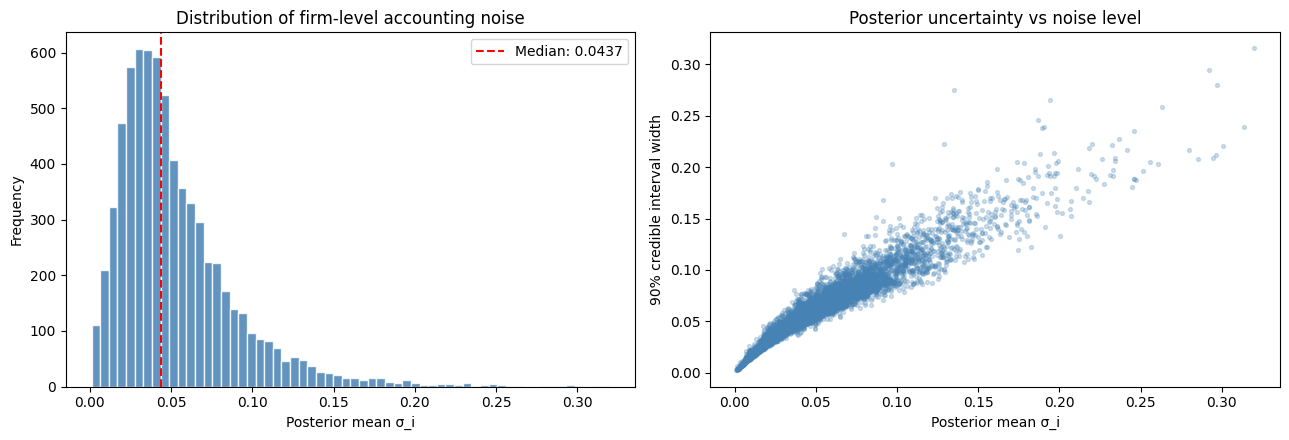

In [15]:
# ────────────────────────────────────────────────────────────
# 1. Distribution of σ_i + posterior uncertainty
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(sigma_summary["sigma_mean"], bins=60,
             edgecolor="white", alpha=0.85, color="steelblue")
axes[0].axvline(sigma_summary["sigma_mean"].median(), color="red", ls="--",
                label=f"Median: {sigma_summary['sigma_mean'].median():.4f}")
axes[0].set_xlabel("Posterior mean σ_i")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of firm-level accounting noise")
axes[0].legend()

sigma_summary["ci_width"] = sigma_summary["sigma_q95"] - sigma_summary["sigma_q05"]
axes[1].scatter(sigma_summary["sigma_mean"], sigma_summary["ci_width"],
                alpha=0.25, s=8, color="steelblue")
axes[1].set_xlabel("Posterior mean σ_i")
axes[1].set_ylabel("90% credible interval width")
axes[1].set_title("Posterior uncertainty vs noise level")

plt.tight_layout()
plt.savefig(PLOT_DIR / "sigma_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/y_/vpxp1t197mzf59bbg2x2qgt80000gn/T/ipykernel_79815/1414709208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=sector_order, showfliers=False, patch_artist=True)


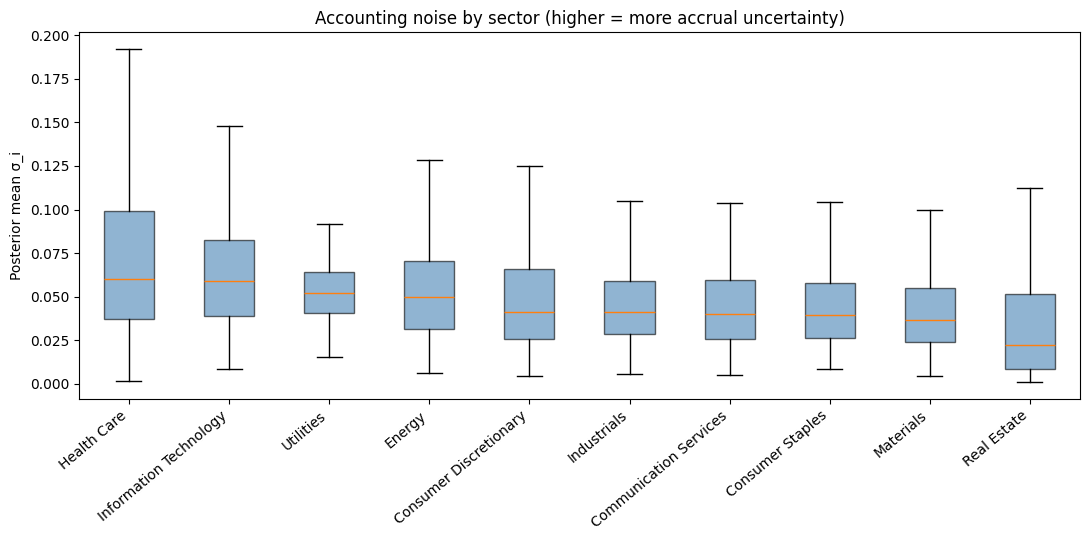

In [16]:
# ────────────────────────────────────────────────────────────
# 2. σ_i by sector (box plot)
# ────────────────────────────────────────────────────────────
sector_order = (
    sigma_with_sector.groupby("Sector")["sigma_mean"].median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 5.5))
box_data = [sigma_with_sector.loc[sigma_with_sector["Sector"] == s, "sigma_mean"]
            for s in sector_order]
bp = ax.boxplot(box_data, labels=sector_order, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)

ax.set_ylabel("Posterior mean σ_i")
ax.set_title("Accounting noise by sector (higher = more accrual uncertainty)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "sigma_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

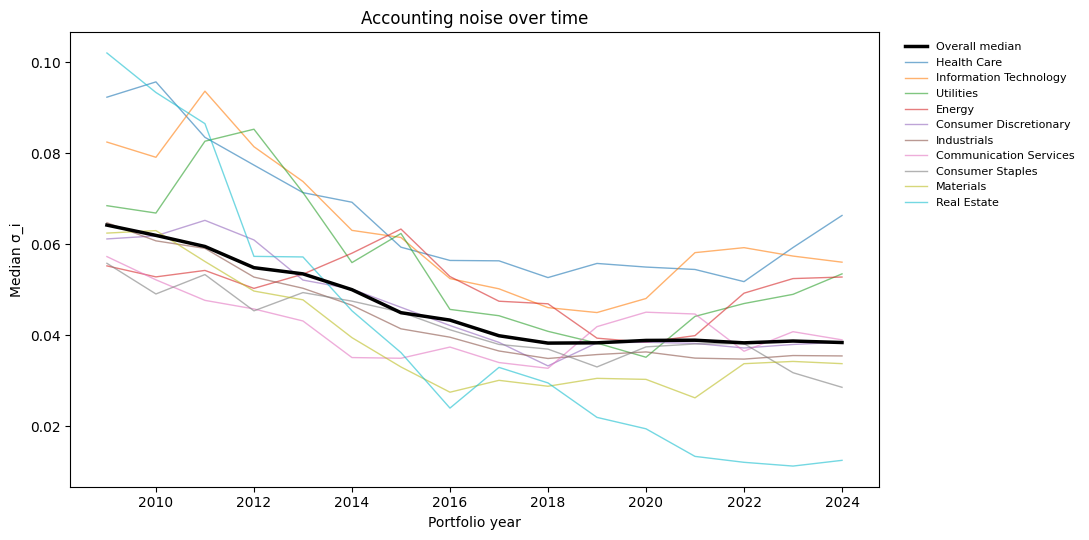

In [17]:
# ────────────────────────────────────────────────────────────
# 3. σ_i over time by sector
# ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))

overall_median = sigma_summary.groupby("Year")["sigma_mean"].median()
ax.plot(overall_median.index, overall_median.values, color="black",
        lw=2.5, label="Overall median", zorder=10)

for sector in sector_order:
    yearly = (sigma_with_sector.loc[sigma_with_sector["Sector"] == sector]
              .groupby("Year")["sigma_mean"].median())
    ax.plot(yearly.index, yearly.values, alpha=0.6, lw=1, label=sector)

ax.set_xlabel("Portfolio year")
ax.set_ylabel("Median σ_i")
ax.set_title("Accounting noise over time")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(PLOT_DIR / "sigma_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

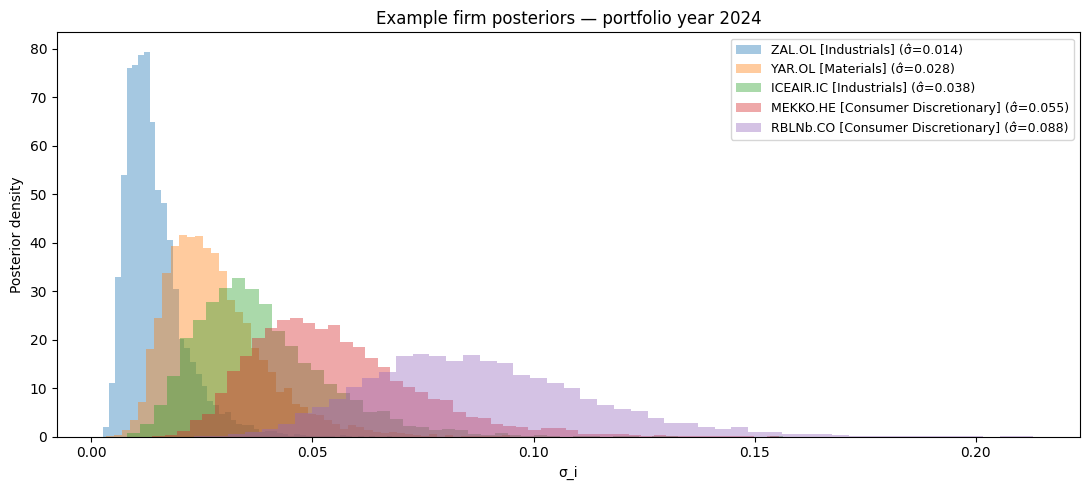


Diagnostic plots saved to ../data/hb_results/ar1/plots


In [18]:
# ────────────────────────────────────────────────────────────
# 4. Example firm posteriors at different σ percentiles
# ────────────────────────────────────────────────────────────
latest_year = max(all_results.keys())
latest_results = all_results[latest_year]
latest_sigma_means = {k: np.mean(v) for k, v in latest_results.items()}
sorted_firms = sorted(latest_sigma_means.items(), key=lambda x: x[1])
n = len(sorted_firms)

if n >= 10:
    example_firms = [sorted_firms[int(n * p)][0] for p in [0.1, 0.3, 0.5, 0.7, 0.9]]

    fig, ax = plt.subplots(figsize=(11, 5))
    for firm_idx in example_firms:
        draws = latest_results[firm_idx]
        ticker = firm_map_rev.get(firm_idx, f"firm_{firm_idx}")
        sec = sector_info.loc[sector_info["Ticker"] == ticker, "Sector"].values
        sec_label = sec[0] if len(sec) else "?"
        ax.hist(draws, bins=50, alpha=0.4, density=True,
                label=f"{ticker} [{sec_label}] (σ̂={np.mean(draws):.3f})")

    ax.set_xlabel("σ_i")
    ax.set_ylabel("Posterior density")
    ax.set_title(f"Example firm posteriors — portfolio year {latest_year}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "sigma_posterior_examples.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Skipping example-firm plot: only {n} firms in {latest_year} (need ≥10).")

print(f"\nDiagnostic plots saved to {PLOT_DIR}")

Sampling: [WCA_obs, cfo_next_obs]


Output()

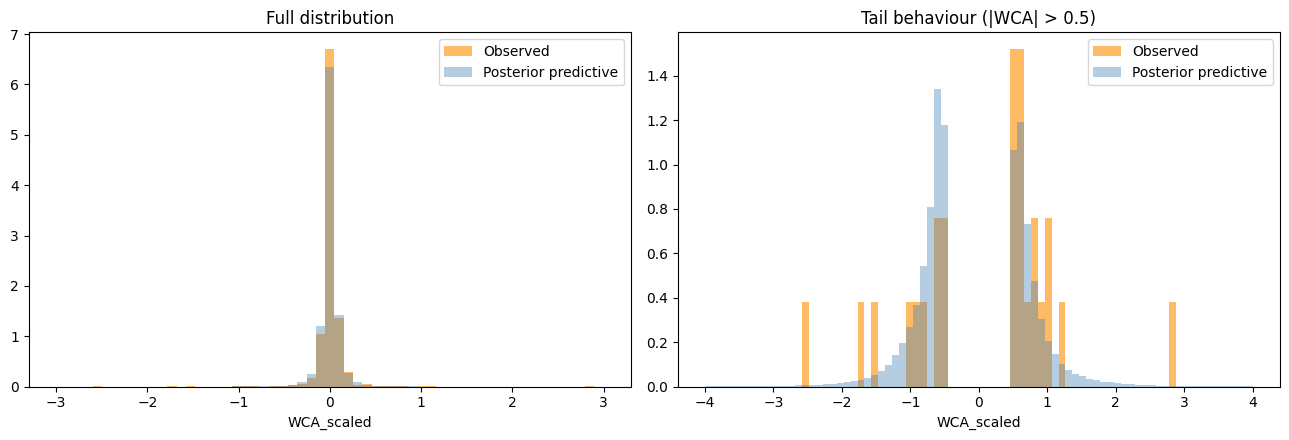

In [21]:
with model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

observed = window_df["WCA_scaled"].values
simulated = ppc.posterior_predictive["WCA_obs"].values.flatten()


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-3, 3, 60)

# Left: full view (clipped to observed range)
axes[0].hist(observed, bins=bins, density=True, alpha=0.6,
             label="Observed", color="darkorange")
axes[0].hist(simulated, bins=bins, density=True, alpha=0.4,
             label="Posterior predictive", color="steelblue")
axes[0].set_xlabel("WCA_scaled")
axes[0].set_title("Full distribution")
axes[0].legend()

# Right: tail zoom (|WCA| > 0.5)
tail_obs = observed[np.abs(observed) > 0.5]
tail_sim = simulated[np.abs(simulated) > 0.5]
bins_tail = np.linspace(-4, 4, 80)
axes[1].hist(tail_obs, bins=bins_tail, density=True, alpha=0.6,
             label="Observed", color="darkorange")
axes[1].hist(tail_sim, bins=bins_tail, density=True, alpha=0.4,
             label="Posterior predictive", color="steelblue")
axes[1].set_xlabel("WCA_scaled")
axes[1].set_title("Tail behaviour (|WCA| > 0.5)")
axes[1].legend()

plt.tight_layout()